In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

資料 https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting

In [2]:
df =  pd.read_csv("sales_data.csv")

In [3]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [4]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [5]:
df["Product ID"].value_counts()

Product ID
P0001    3800
P0002    3800
P0019    3800
P0018    3800
P0017    3800
P0016    3800
P0015    3800
P0014    3800
P0013    3800
P0012    3800
P0011    3800
P0010    3800
P0009    3800
P0008    3800
P0007    3800
P0006    3800
P0005    3800
P0004    3800
P0003    3800
P0020    3800
Name: count, dtype: int64

In [6]:
df = df.drop(columns=['Date'],axis = 1)

In [7]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing"
]

scaler = MinMaxScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,S001,P0001,Electronics,North,0.086017,0.239437,0.155941,0.304447,0.2,Snowy,0,0.316973,Winter,0,115
1,S001,P0002,Clothing,North,0.051610,0.274648,0.154084,0.337767,0.6,Snowy,1,0.341455,Winter,0,229
2,S001,P0003,Clothing,North,0.108955,0.267606,0.378713,0.260648,0.4,Snowy,1,0.217141,Winter,0,157
3,S001,P0004,Electronics,North,0.061315,0.105634,0.063119,0.371221,0.4,Snowy,0,0.314872,Winter,0,52
4,S001,P0005,Groceries,North,0.067049,0.152582,0.167698,0.222446,0.0,Snowy,0,0.184253,Winter,0,59


In [8]:
categorical_cols = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== Store ID =====
Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64

===== Product ID =====
Product ID
P0001    3800
P0002    3800
P0019    3800
P0018    3800
P0017    3800
P0016    3800
P0015    3800
P0014    3800
P0013    3800
P0012    3800
P0011    3800
P0010    3800
P0009    3800
P0008    3800
P0007    3800
P0006    3800
P0005    3800
P0004    3800
P0003    3800
P0020    3800
Name: count, dtype: int64

===== Category =====
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

===== Region =====
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

===== Weather Condition =====
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

===== Seasonality =====
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtyp

In [9]:
target = "Demand"

categorical_cols = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

X = df.drop(columns=[target])
y = df[target]

In [10]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [11]:
print(X.shape)
X.head()

(76000, 44)


,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Store ID_S002,Store ID_S003,...,Category_Toys,Region_North,Region_South,Region_West,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,0.086017,0.239437,0.155941,0.304447,0.2,0,0.316973,0,0,0,...,0,1,0,0,0,1,0,0,0,1
1,0.051610,0.274648,0.154084,0.337767,0.6,1,0.341455,0,0,0,...,0,1,0,0,0,1,0,0,0,1
2,0.108955,0.267606,0.378713,0.260648,0.4,1,0.217141,0,0,0,...,0,1,0,0,0,1,0,0,0,1
3,0.061315,0.105634,0.063119,0.371221,0.4,0,0.314872,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,0.067049,0.152582,0.167698,0.222446,0.0,0,0.184253,0,0,0,...,0,1,0,0,0,1,0,0,0,1


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (60800, 44)
Test: (15200, 44)


In [13]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(
    score_func=f_regression,
    k="all"
)

selector.fit(X_train, y_train)

SelectKBest(k='all', score_func=<function f_regression at 0x000001CA0A0D0360>)

In [14]:
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "F_Score": selector.scores_,
    "P_Value": selector.pvalues_
})

feature_scores = feature_scores.sort_values(
    by="F_Score",
    ascending=False
)

feature_scores

,Feature,F_Score,P_Value
1,Units Sold,137207.429068,0.000000e+00
2,Units Ordered,21495.847332,0.000000e+00
7,Epidemic,9303.635773,0.000000e+00
32,Category_Furniture,6317.223660,0.000000e+00
33,Category_Groceries,5583.408030,0.000000e+00
5,Promotion,5197.681632,0.000000e+00
4,Discount,3177.425107,0.000000e+00
40,Weather Condition_Sunny,1417.727013,1.023004e-306
0,Inventory Level,972.372642,8.584070e-212
38,Weather Condition_Rainy,700.009058,2.211201e-153


In [16]:
selected_features = feature_scores[
    feature_scores["P_Value"] < 0.05
]["Feature"].tolist()

print("Selected features:")
print(selected_features)

Selected features:
['Units Sold', 'Units Ordered', 'Epidemic', 'Category_Furniture', 'Category_Groceries', 'Promotion', 'Discount', 'Weather Condition_Sunny', 'Inventory Level', 'Weather Condition_Rainy', 'Seasonality_Summer', 'Category_Toys', 'Product ID_P0020', 'Weather Condition_Snowy', 'Seasonality_Spring', 'Product ID_P0009', 'Product ID_P0012', 'Product ID_P0017', 'Product ID_P0013', 'Category_Electronics', 'Product ID_P0004', 'Product ID_P0007', 'Store ID_S004', 'Region_West', 'Product ID_P0014', 'Product ID_P0002', 'Product ID_P0010', 'Product ID_P0019', 'Store ID_S003', 'Product ID_P0018', 'Region_South', 'Store ID_S002', 'Price', 'Competitor Pricing', 'Product ID_P0016', 'Product ID_P0005', 'Product ID_P0006', 'Product ID_P0011', 'Store ID_S005', 'Seasonality_Winter', 'Region_North']


In [17]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
if len(selected_features) == 0:
    selected_features = feature_scores.head(10)["Feature"].tolist()

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_selected,
    y_train
)

y_pred = model.predict(X_test_selected)

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 16.273954765911988
RMSE: 21.819680492182737
R²  : 0.7844260536806613


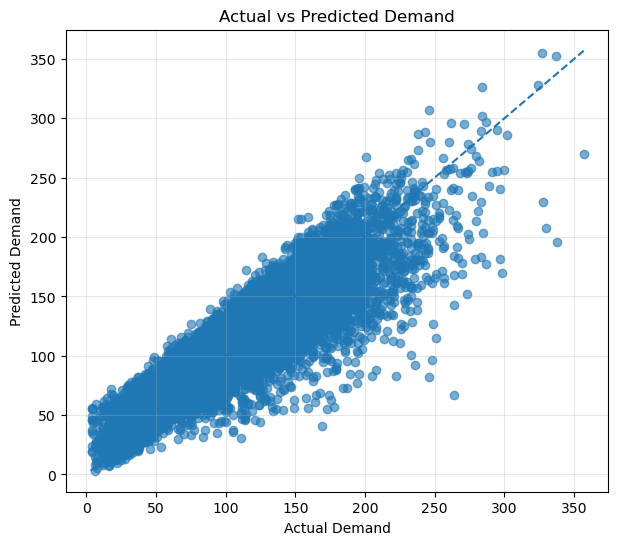

In [21]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val], 
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.grid(alpha=0.3)

plt.show()

In [24]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(
    X_train_selected.astype(float)
)

X_test_sm = sm.add_constant(
    X_test_selected.astype(float),
    has_constant="add"
)

ols_model = sm.OLS(
    y_train.astype(float),
    X_train_sm
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     5594.
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        10:03:27   Log-Likelihood:            -2.7459e+05
No. Observations:               60800   AIC:                         5.493e+05
Df Residuals:                   60761   BIC:                         5.496e+05
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [25]:
prediction = ols_model.get_prediction(X_test_sm)

prediction_summary = prediction.summary_frame(alpha=0.05)

print(prediction_summary.head())

             mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
53731  107.144027  0.584549     105.998310     108.289745     63.722282   
61112   83.177596  0.560229      82.079545      84.275647     39.757082   
72074   38.635065  0.459758      37.733939      39.536191     -4.780915   
56928  167.091447  0.552708     166.008138     168.174756    123.671303   
20979  101.302002  0.533157     100.257013     102.346992     57.882798   

       obs_ci_upper  
53731    150.565773  
61112    126.598110  
72074     82.051045  
56928    210.511591  
20979    144.721207  


In [26]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": prediction_summary["mean"].values,
    "Lower_PI": prediction_summary["obs_ci_lower"].values,
    "Upper_PI": prediction_summary["obs_ci_upper"].values
})

results = results.sort_values("Predicted").reset_index(drop=True)

print(results.head())

   Actual  Predicted   Lower_PI   Upper_PI
0       6   3.126406 -40.290916  46.543729
1       8   5.238252 -38.179125  48.655628
2      16   6.871953 -36.545366  50.289273
3      12   7.711445 -35.710382  51.133273
4       6   8.223699 -35.192504  51.639902


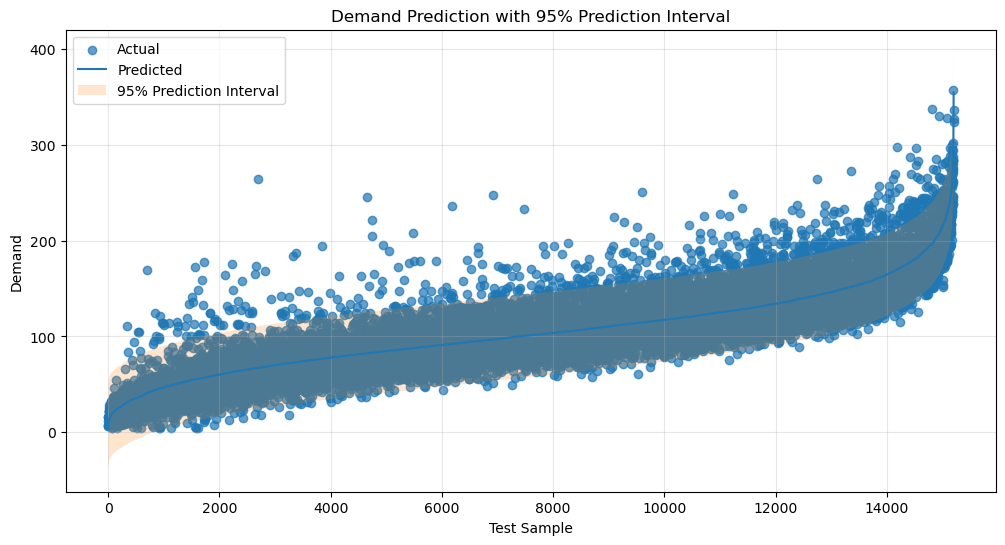

In [ ]:
plt.figure(figsize=(12, 6))

x = np.arange(len(results))

plt.scatter(
    x,
    results["Actual"],
    label="Actual",
    alpha=0.7
)

plt.plot(
    x,
    results["Predicted"],
    label="Predicted"
)

plt.fill_between(
    x,
    results["Lower_PI"],
    results["Upper_PI"],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.xlabel("Test Sample")
plt.ylabel("Demand")

plt.title(
    "Demand Prediction with 95% Prediction Interval"
)
    
plt.legend()

plt.grid(alpha=0.3)

plt.show()